In [1]:
# Adjust import path
import sys
sys.path.append("../things")
sys.path.append("helpers")
sys.path.append("../")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation 
from IPython.display import HTML

import os
import numpy as np
import matplotlib.pyplot as plt
import opinf
import config
import utils
import step1_generate_data as step1

Logging to log.log


#### Setup

In [2]:
training_span = (0, 1)
num_samples = 65
noiselevel = .01
num_regression_points = 150
numPODmodes = 5
ndraws = 600
time_domain_eval_training = np.linspace(0, training_span[-1], num_regression_points)
normalization = 1e-4
gp_normalization = 1e-4
num_initial_conditions = len(config.input_parameters)

### Generate & Visualize Data

In [3]:
utils.summarize_experiment(
    training_span=training_span,
    num_samples=num_samples,
    noiselevel=noiselevel,
    num_regression_points=num_regression_points,
    numPODmodes=numPODmodes,
    gp_regularizer=normalization,
    ndraws=ndraws,
)

sampler = step1.TrajectorySampler(
    training_span,
    num_samples,
    noiselevel,
    num_regression_points,
    synced=False,
)
(
    true_states,
    time_domain_sampled,
    snapshots_sampled,
    training_inputs,
) = sampler.multisample(config.input_parameters, plot=False)

(
    true_states_new_initial,
    time_domain_sampled_new_initial,
    snapshots_sampled_new_initial,
    training_inputs_new_initial,
) = sampler.sample(config.test_parameters)

time_domain = config.time_domain

true_states, time_domain_sampled, snapshots_sampled, training_inputs = np.array(true_states), np.array(time_domain_sampled), np.array(snapshots_sampled), np.array(training_inputs)
true_states.shape, time_domain_sampled.shape, snapshots_sampled.shape, training_inputs.shape, time_domain_eval_training.shape, time_domain.shape, snapshots_sampled_new_initial.shape, training_inputs_new_initial.shape



EXPERIMENTAL SCENARIO
Data:
	* 5 trajectories
	* 65 randomly sampled snapshots in each trajectory
	* 1.00% noise
	* training   0.00 ≤ t < 1.00
	* prediction 0.00 ≤ t ≤ 2.00
Dimension: retaining 5 POD modes
Training: using 150 regression points
GP regularization: eta = 1.00e-04
Posterior: 600 draws



((5, 500, 500),
 (5, 65),
 (5, 500, 65),
 (5, 2, 150),
 (150,),
 (500,),
 (500, 65),
 (2, 150))

### Fit Basis

reducing noisy training states to 5 dimensions...done in 0.17 s.
(5, 5, 65) (5, 65) (5, 65) (65,)


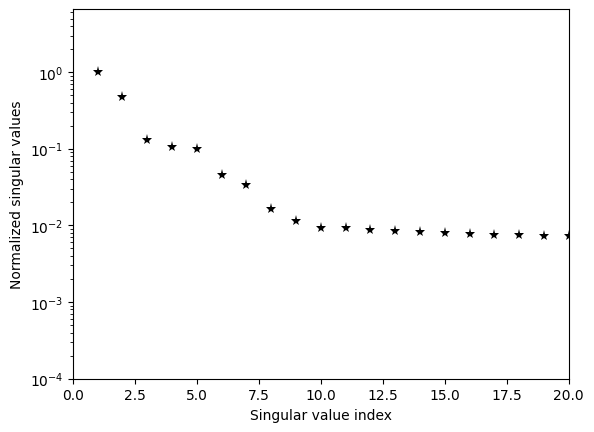

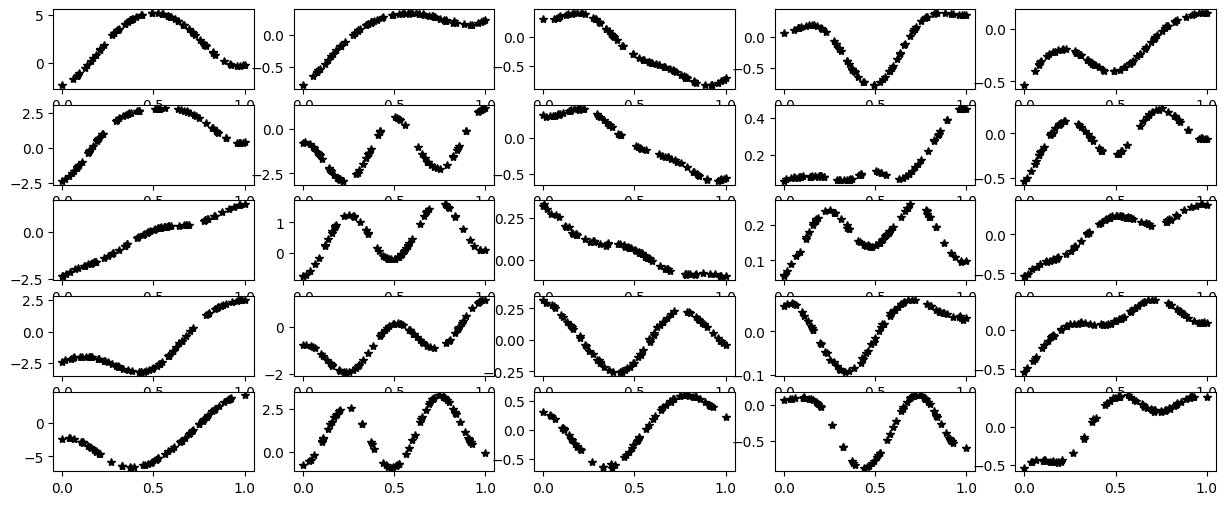

In [4]:
# Start Cell
with opinf.utils.TimedBlock(
    f"reducing noisy training states to {numPODmodes} dimensions"
):
    basis = config.Basis(num_vectors=numPODmodes)
    basis.fit(np.hstack(snapshots_sampled))
    ax = basis.plot_svdval_decay()
    ax.set_xlim(right=20)
    ax.set_ylim(bottom=1e-4)
    # utils.save_figure("svdvals.pdf", andopen=openonsave)
    snapshots_compressed = [basis.compress(Q) for Q in snapshots_sampled]
    full_states_compressed = [basis.compress(Q) for Q in true_states]
    snapshots_compressed_new_initial = basis.compress(snapshots_sampled_new_initial)
    full_states_compressed_new_initial = basis.compress(true_states_new_initial)

snapshots_compressed = np.array(snapshots_compressed)
full_states_compressed = np.array(full_states_compressed)
snapshots_compressed_new_initial = np.array(snapshots_compressed_new_initial)
full_states_compressed_new_initial = np.array(full_states_compressed_new_initial)
print(snapshots_compressed.shape, time_domain_sampled.shape, snapshots_compressed_new_initial.shape, time_domain_sampled_new_initial.shape)

fig, ax = plt.subplots(num_initial_conditions, numPODmodes, figsize=(15, 6))
for i in range(num_initial_conditions):
    for j in range(numPODmodes):
        ax[i,j].plot(time_domain_sampled[i], snapshots_compressed[i,j], 'k*', label='True')

In [5]:
import step2_fitgps as step2

# Fit Gaussian process kernels to the compressed training data.
gps = []  # indexed by trajectory, then reduced mode.
for i, (t, Q) in enumerate(zip(time_domain_sampled, snapshots_compressed)):
    print(f"\n*** Trajectory {i+1} ***")
    gps.append(
        step2.fit_gaussian_processes(
            time_domain_training=sampler.training_time_domain,
            time_domain_sampled=t,
            snapshots_sampled=Q,
            gp_regularizer=gp_normalization,
        )
    )
q0s = [
    np.array([gp.state_estimate[0] for gp in gps[ell]])
    for ell in range(len(config.input_parameters))
]
q0s = [ np.array([gp.state_estimate[0] for gp in gps[ell]]) for ell in range(len(config.input_parameters))]



*** Trajectory 1 ***

fitting GP model for state 'r01'...
Gaussian radial basis function kernel
	k(t, t') = \sigma^2 exp(-(t - t')^2 / (2 \ell^2)) + \chi I
	\sigma^2 = 1.0411e+01
	\ell = 2.7162e-01
	\chi = 2.0026e-05
done in 6.70 s.
computing weight matrix...done in 0.06 s.

fitting GP model for state 'r02'...
Gaussian radial basis function kernel
	k(t, t') = \sigma^2 exp(-(t - t')^2 / (2 \ell^2)) + \chi I
	\sigma^2 = 3.1579e-01
	\ell = 2.9796e-01
	\chi = 2.6372e-05
done in 15.09 s.
computing weight matrix...done in 0.08 s.

fitting GP model for state 'r03'...


/home/anthonypoole/miniconda3/envs/prob-rom-inf/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 9 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


Gaussian radial basis function kernel
	k(t, t') = \sigma^2 exp(-(t - t')^2 / (2 \ell^2)) + \chi I
	\sigma^2 = 3.2616e-01
	\ell = 2.2959e-01
	\chi = 8.4046e-06
done in 24.73 s.
computing weight matrix...done in 0.08 s.

fitting GP model for state 'r04'...
Gaussian radial basis function kernel
	k(t, t') = \sigma^2 exp(-(t - t')^2 / (2 \ell^2)) + \chi I
	\sigma^2 = 2.7702e-01
	\ell = 2.2173e-01
	\chi = 2.7052e-06
done in 16.99 s.
computing weight matrix...done in 0.10 s.

fitting GP model for state 'r05'...
Gaussian radial basis function kernel
	k(t, t') = \sigma^2 exp(-(t - t')^2 / (2 \ell^2)) + \chi I
	\sigma^2 = 2.2104e-01
	\ell = 2.6762e-01
	\chi = 2.1772e-05
done in 49.18 s.
computing weight matrix...done in 0.13 s.

*** Trajectory 2 ***

fitting GP model for state 'r01'...
Gaussian radial basis function kernel
	k(t, t') = \sigma^2 exp(-(t - t')^2 / (2 \ell^2)) + \chi I
	\sigma^2 = 1.0072e+01
	\ell = 2.7249e-01
	\chi = 3.6205e-05
done in 48.47 s.
computing weight matrix...done in 0.1

/home/anthonypoole/miniconda3/envs/prob-rom-inf/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 20 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


Gaussian radial basis function kernel
	k(t, t') = \sigma^2 exp(-(t - t')^2 / (2 \ell^2)) + \chi I
	\sigma^2 = 2.4238e+00
	\ell = 1.8539e-01
	\chi = 2.3269e-05
done in 56.16 s.
computing weight matrix...done in 0.13 s.

fitting GP model for state 'r03'...
Gaussian radial basis function kernel
	k(t, t') = \sigma^2 exp(-(t - t')^2 / (2 \ell^2)) + \chi I
	\sigma^2 = 6.0253e-02
	\ell = 2.2740e-01
	\chi = 4.2027e-05
done in 50.77 s.
computing weight matrix...done in 0.13 s.

fitting GP model for state 'r04'...
Gaussian radial basis function kernel
	k(t, t') = \sigma^2 exp(-(t - t')^2 / (2 \ell^2)) + \chi I
	\sigma^2 = 2.9145e-03
	\ell = 1.4917e-01
	\chi = 3.5730e-06
done in 46.87 s.
computing weight matrix...done in 0.14 s.

fitting GP model for state 'r05'...
Gaussian radial basis function kernel
	k(t, t') = \sigma^2 exp(-(t - t')^2 / (2 \ell^2)) + \chi I
	\sigma^2 = 2.0111e-01
	\ell = 2.3658e-01
	\chi = 3.5616e-05
done in 44.88 s.
computing weight matrix...done in 0.11 s.

*** Trajectory 5

...

Gaussian radial basis function kernel
	k(t, t') = \sigma^2 exp(-(t - t')^2 / (2 \ell^2)) + \chi I
	\sigma^2 = 4.0637e+00
	\ell = 1.6178e-01
	\chi = 4.7490e-05
done in 58.98 s.
computing weight matrix...done in 0.12 s.

fitting GP model for state 'r03'...
Gaussian radial basis function kernel
	k(t, t') = \sigma^2 exp(-(t - t')^2 / (2 \ell^2)) + \chi I
	\sigma^2 = 2.2380e-01
	\ell = 2.4245e-01
	\chi = 7.6224e-05
done in 52.46 s.
computing weight matrix...done in 0.11 s.

fitting GP model for state 'r04'...


/home/anthonypoole/miniconda3/envs/prob-rom-inf/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 1 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


Gaussian radial basis function kernel
	k(t, t') = \sigma^2 exp(-(t - t')^2 / (2 \ell^2)) + \chi I
	\sigma^2 = 1.8471e-01
	\ell = 1.6448e-01
	\chi = 7.3035e-06
done in 56.90 s.
computing weight matrix...done in 0.10 s.

fitting GP model for state 'r05'...


/home/anthonypoole/miniconda3/envs/prob-rom-inf/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 14 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


Gaussian radial basis function kernel
	k(t, t') = \sigma^2 exp(-(t - t')^2 / (2 \ell^2)) + \chi I
	\sigma^2 = 1.6973e-01
	\ell = 1.7283e-01
	\chi = 7.3328e-05
done in 57.29 s.
computing weight matrix...done in 0.16 s.


In [6]:
q0_new_initial = np.array([gps[-1][podMode].predict(time_domain_eval_training)[0][0] for podMode in range(numPODmodes)])
q0_new_initial.shape

(5,)

In [7]:
import step3_estimate as step3

# Step 3: Construct the posterior hyperparameters -------------------------
bayesian_model = step3.estimate_posterior(
    prediction_time_domain=sampler.prediction_time_domain,
    gps=gps,
    training_inputs=training_inputs,
    initial_conditions=q0s,
)

constructing posterior hyperparameters...


INFO:2025-10-02 10:35:08,411:jax._src.xla_bridge:822: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory



GRIDSEARCH
(1/81) Testing regularizer 1.0000e-16...UNSTABLE
(2/81) Testing regularizer 1.7783e-16...UNSTABLE
(3/81) Testing regularizer 3.1623e-16...0.28% error
(4/81) Testing regularizer 5.6234e-16...UNSTABLE
(5/81) Testing regularizer 1.0000e-15...UNSTABLE
(6/81) Testing regularizer 1.7783e-15...0.28% error
(7/81) Testing regularizer 3.1623e-15...UNSTABLE
(8/81) Testing regularizer 5.6234e-15...UNSTABLE
(9/81) Testing regularizer 1.0000e-14...0.28% error
(10/81) Testing regularizer 1.7783e-14...UNSTABLE
(11/81) Testing regularizer 3.1623e-14...UNSTABLE
(12/81) Testing regularizer 5.6234e-14...UNSTABLE
(13/81) Testing regularizer 1.0000e-13...UNSTABLE
(14/81) Testing regularizer 1.7783e-13...UNSTABLE
(15/81) Testing regularizer 3.1623e-13...UNSTABLE
(16/81) Testing regularizer 5.6234e-13...UNSTABLE
(17/81) Testing regularizer 1.0000e-12...UNSTABLE
(18/81) Testing regularizer 1.7783e-12...UNSTABLE
(19/81) Testing regularizer 3.1623e-12...0.29% error
(20/81) Testing regularizer 5.6234e

In [8]:
print("Huh")
print(sampler.prediction_time_domain.shape)
print("huh")

Huh
(500,)
huh


In [9]:
def draws_for_single_trajectory(params, q0, snaps_compressed):
    input_func = config.input_func_factory(params)
    qbar = snaps_compressed.mean(axis=1).reshape((-1, 1))
    bound = 5 * np.max(np.abs(snaps_compressed - qbar), axis=1)

    num_unstables = 0
    prediction_draws_compressed = []
    training_draws_compressed = []
    for _ in range(ndraws):
        prediction_draw = bayesian_model.predict(
            q0,
            sampler.prediction_time_domain,
            input_func=input_func,
        )
        training_draw = bayesian_model.predict(
            q0,
            time_domain_eval_training,
            input_func=input_func,
        )
        if prediction_draw.shape[1] != sampler.prediction_time_domain.size:
            num_unstables += 1
            continue
        if np.any(np.abs(prediction_draw - qbar).max(axis=1) > bound):
            num_unstables += 1
            continue
        prediction_draws_compressed.append(prediction_draw)
        training_draws_compressed.append(training_draw)
    if num_unstables:
        print(f"\n{num_unstables}/{ndraws} draws unstable")

    # Translate results back to original state space.
    prediction_draws_uncompressed = [basis.decompress(draw) for draw in prediction_draws_compressed]
    training_draws_uncompressed = [basis.decompress(draw) for draw in training_draws_compressed]
    return prediction_draws_compressed, prediction_draws_uncompressed, training_draws_compressed, training_draws_uncompressed

# Draw samples from the posterior (for now at the same model parameters).
with opinf.utils.TimedBlock("sampling posterior distribution"):
    all_prediction_draws_compressed, all_prediction_draws_decompressed, all_training_draws_compressed, all_training_draws_decompressed = [], [], [], []
    for ell, params in enumerate(config.input_parameters):
        prediction_draws_compressed, prediction_draws_decompressed, training_draws_compressed, training_draws_decompressed = draws_for_single_trajectory(
            params,
            q0s[ell],
            snapshots_compressed[ell],
        )
        all_prediction_draws_compressed.append(prediction_draws_compressed)
        all_prediction_draws_decompressed.append(prediction_draws_decompressed)
        all_training_draws_compressed.append(training_draws_compressed)
        all_training_draws_decompressed.append(training_draws_decompressed)
    
    prediction_draws_compressed_new_initial, prediction_draws_decompressed_new_initial, training_draws_compressed_new_initial, training_draws_decompressed_new_initial = draws_for_single_trajectory(
        config.test_parameters,
        q0_new_initial,
        snapshots_compressed_new_initial,
    )

# Step 4: plot results ----------------------------------------------------
# Initialize reduced plotter.
true_states_compressed = [basis.compress(Q) for Q in true_states]
true_states_projected = [
    basis.decompress(Q_) for Q_ in true_states_compressed
]

sampling posterior distribution...

/home/anthonypoole/miniconda3/envs/prob-rom-inf/lib/python3.13/site-packages/opinf/models/mono/_nonparametric.py:1050: IntegrationWarning: Required step size is less than spacing between numbers.
  warnings.warn(out.message, spintegrate.IntegrationWarning)



24/600 draws unstable
done in 127.22 s.


In [10]:
true_states_compressed_new_initial = basis.compress(true_states_new_initial)

true_states_compressed_new_initial = np.expand_dims(np.array(true_states_compressed_new_initial), axis=0)
true_states_compressed = np.array(true_states_compressed)

true_states_compressed = np.concatenate((true_states_compressed, true_states_compressed_new_initial), axis=0)

true_states_compressed.shape

(6, 5, 500)

In [11]:
import numpy as np


def truncate_draws(draws):
    # find minimum number of draws across the 5 lists
    min_draws = min(len(inner) for inner in draws)
    print("min_draws =", min_draws)

    # truncate each inner list to min_draws
    draws = [inner[:min_draws] for inner in draws]

    # optionally convert into a single numpy array:
    # result shape will be (5, min_draws, 5, 500)
    return np.permute_dims(np.stack([np.stack(inner, axis=0) for inner in draws], axis=0), (1,0,2,3)) # shape (min_draws, intial, podmodes, 500)

all_prediction_draws_compressed = truncate_draws(all_prediction_draws_compressed)
all_prediction_draws_decompressed = truncate_draws(all_prediction_draws_decompressed)
all_training_draws_compressed = truncate_draws(all_training_draws_compressed)
all_training_draws_decompressed = truncate_draws(all_training_draws_decompressed)
training_draws_compressed_new_initial = np.array(training_draws_compressed_new_initial)
prediction_draws_compressed_new_initial = np.array(prediction_draws_compressed_new_initial)


min_draws = 576
min_draws = 576
min_draws = 576
min_draws = 576


In [12]:
print(np.expand_dims(training_draws_compressed_new_initial, axis=1).shape, all_training_draws_compressed.shape)

training_draws_compressed = np.concatenate((all_training_draws_compressed, np.expand_dims(training_draws_compressed_new_initial, axis=1)[:all_training_draws_compressed.shape[0]]), axis=1)
prediction_draws_compressed = np.concatenate((all_prediction_draws_compressed, np.expand_dims(prediction_draws_compressed_new_initial, axis=1)[:all_prediction_draws_compressed.shape[0]]), axis=1)

training_draws_compressed.shape, prediction_draws_compressed.shape

(600, 1, 5, 150) (576, 5, 5, 150)


((576, 6, 5, 150), (576, 6, 5, 500))

In [13]:
lengthscales = np.array([gps[i][j].gpr.kernel_.k1.k2.length_scale for i in range(num_initial_conditions) for j in range(numPODmodes)]).reshape((-1, num_initial_conditions, numPODmodes))
variances = np.array([gps[i][j].gpr.kernel_.k1.k1.constant_value for i in range(num_initial_conditions) for j in range(numPODmodes)]).reshape((-1, num_initial_conditions, numPODmodes))
noises = np.array([gps[i][j].gpr.kernel_.k2.noise_level for i in range(num_initial_conditions) for j in range(numPODmodes)]).reshape((-1, num_initial_conditions, numPODmodes))
print("Lengthscales shape:", lengthscales.shape)
print("Variances shape:", variances.shape)
print("Noises shape:", noises.shape)

Lengthscales shape: (1, 5, 5)
Variances shape: (1, 5, 5)
Noises shape: (1, 5, 5)


/home/anthonypoole/miniconda3/envs/prob-rom-inf/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<Figure size 2000x1200 with 0 Axes>

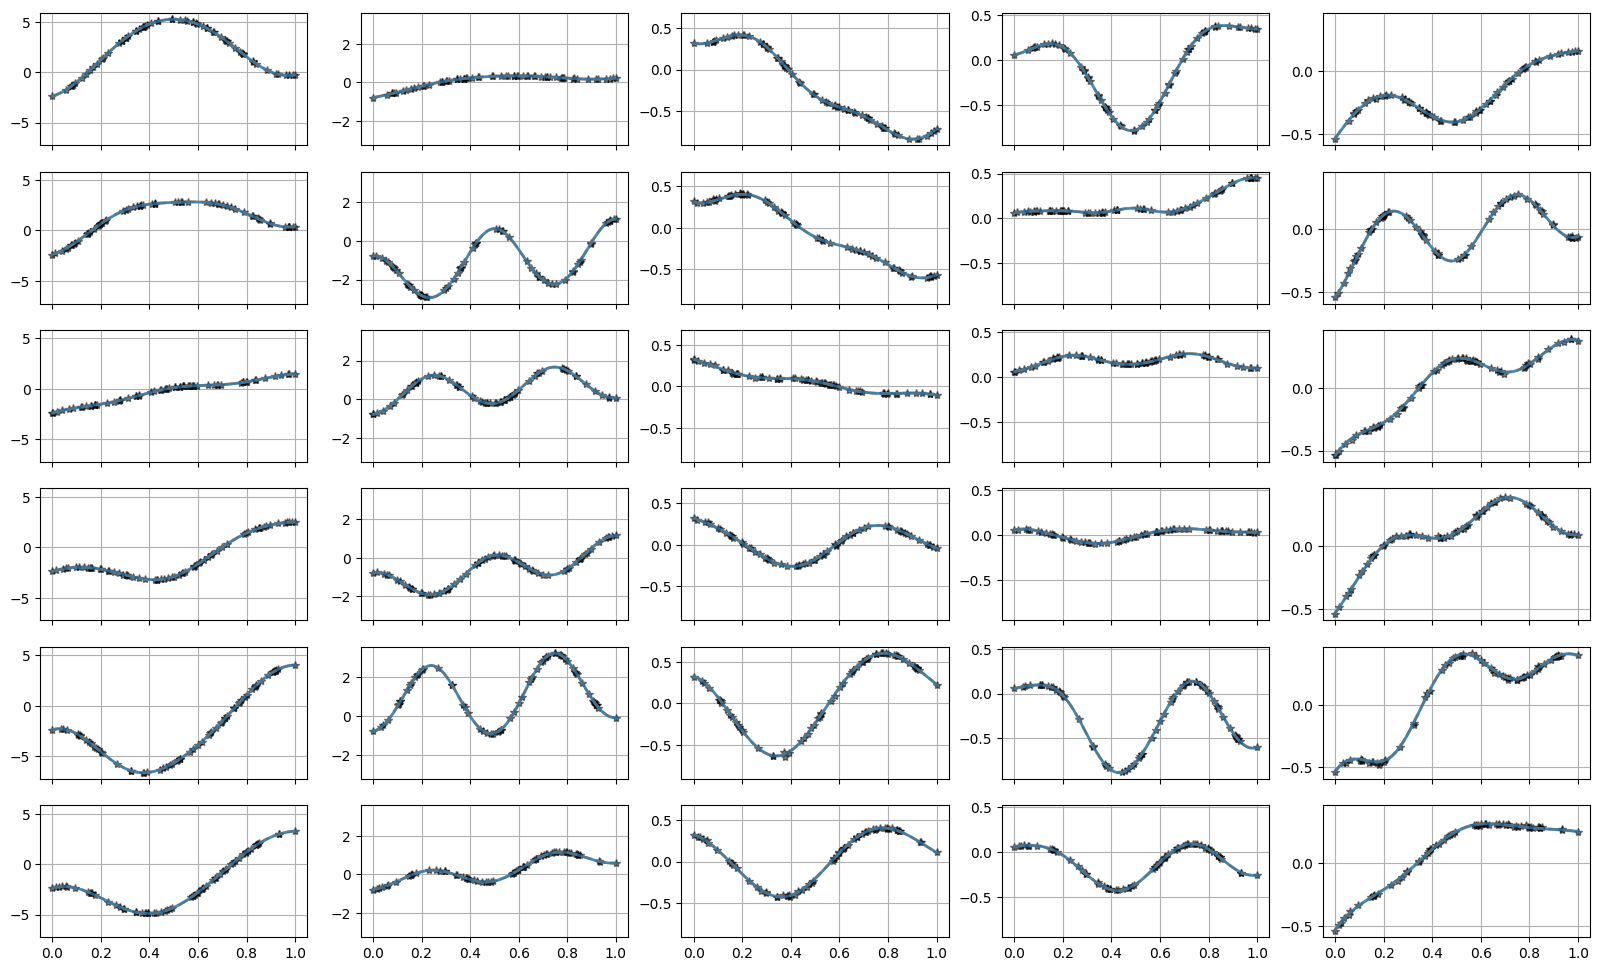

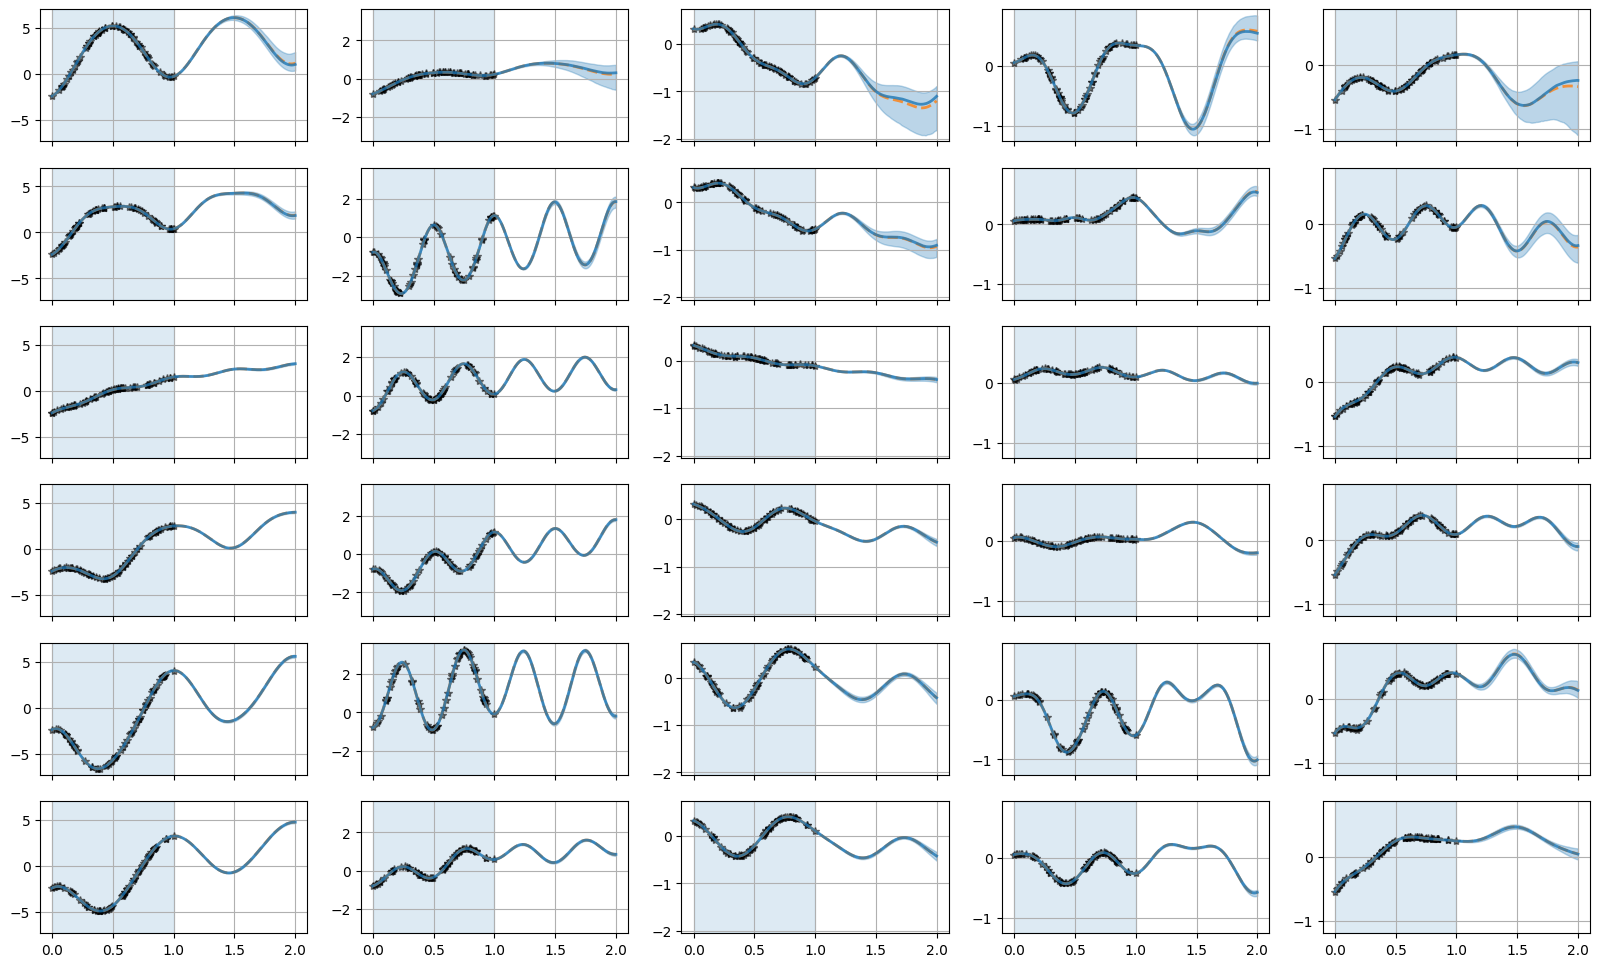

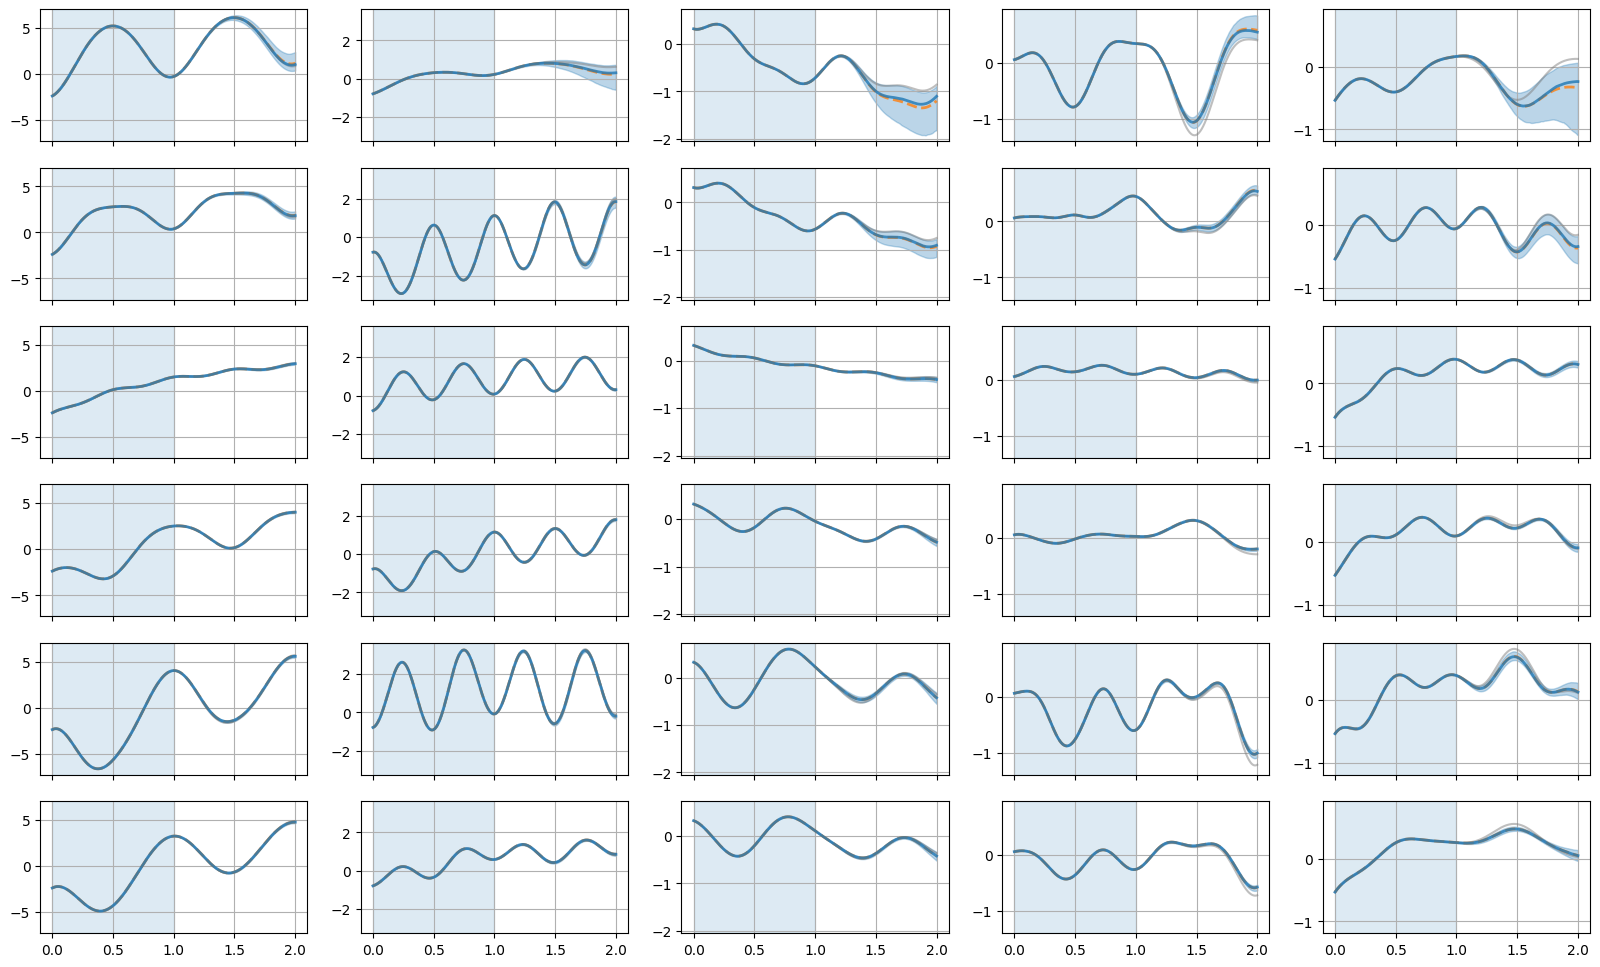

In [14]:
# Plot posterior samples
import heat_plotter
import importlib
importlib.reload(heat_plotter)

plotter = heat_plotter.HeatPlotter(
            numPODmodes=numPODmodes,
            time_domain_training=time_domain_sampled, 
            time_domain_eval_training=time_domain_eval_training,
            time_domain_prediction=time_domain,
            time_domain_eval_prediction=time_domain, # Use full time domain for eval as used in the full order states
            snapshots_training=snapshots_compressed, 
            snapshots_prediction=full_states_compressed,
            )
plotter.gp_plot_states_hyperparams(
    lengthscales, # Shape (samples, num_initial_conditions, numPODmodes)
    variances,    # Shape (samples, num_initial_conditions, numPODmodes)
    noises,       # Shape (samples, num_initial_conditions, numPODmodes)
    figsize=(20,12),
    )

plotter.operator_plot_trajectories(
    snapshots_training_new_initial=snapshots_compressed_new_initial,
    time_domain_training_new_initial=time_domain_sampled_new_initial,
    draws_training=training_draws_compressed,
    draws_prediction=prediction_draws_compressed,
    time_domain_prediction=time_domain,
    time_domain_training_prediction_parameters=time_domain_sampled,
    true_states_compressed=true_states_compressed,
    figsize=(20,12),
    max_num_samples = 100,
)